# N3 - Modelagem Preditiva, Avaliacao e Rastreio de Experimentos

Case: previsao diaria do volume de perguntas do Stack Overflow sobre tecnologias monitoradas (`python`, `reactjs`, `docker`, `vue.js` e tags relacionadas coletadas pela API).

Objetivo: transformar o dataset ja tratado do projeto `stack_overflow` em uma serie temporal diaria, auditar qualidade, criar features, comparar baselines e modelos, diagnosticar residuos, registrar experimentos no wandb e gerar uma previsao final de 30 dias.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

warnings.filterwarnings("ignore")

ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "stack_overflow_n2" / "data" / "questions_for_ml.csv").exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError("Nao encontrei stack_overflow_n2/data/questions_for_ml.csv a partir do diretorio atual.")

STACK_FOR_ML = ROOT / "stack_for_ml"
os.environ.setdefault("WANDB_MODE", "offline")
os.environ.setdefault("WANDB_DIR", str(ROOT / "wandb"))
os.environ.setdefault("WANDB_CACHE_DIR", str(ROOT / "wandb" / "cache"))
os.environ.setdefault("WANDB_CONFIG_DIR", str(ROOT / "wandb" / "config"))
os.environ.setdefault("WANDB_DATA_DIR", str(ROOT / "wandb" / "data"))
os.environ.setdefault("TMP", str(ROOT / ".tmp_wandb"))
os.environ.setdefault("TEMP", str(ROOT / ".tmp_wandb"))
os.environ.setdefault("TMPDIR", str(ROOT / ".tmp_wandb"))
os.environ.setdefault("IPYTHONDIR", str(ROOT / ".tmp_ipython"))
for env_dir in ["WANDB_DIR", "WANDB_CACHE_DIR", "WANDB_CONFIG_DIR", "WANDB_DATA_DIR", "TMP", "IPYTHONDIR"]:
    Path(os.environ[env_dir]).mkdir(parents=True, exist_ok=True)
tempfile.tempdir = os.environ["TMP"]
sys.path.insert(0, str(STACK_FOR_ML))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

from src.timeseries_utils import (
    DEFAULT_FEATURES,
    TARGET,
    add_time_features,
    baseline_moving_average,
    baseline_persistence,
    build_daily_series,
    fit_exponential_smoothing,
    fit_ml_model,
    fit_sarimax_grid,
    load_questions,
    log_wandb_run,
    quality_diagnostic,
    residual_diagnostics,
    temporal_split,
    walk_forward_sarimax,
)

sns.set_theme(style="whitegrid", context="notebook")
CSV_PATH = ROOT / "stack_overflow_n2" / "data" / "questions_for_ml.csv"
PROJECT_NAME = "stack-overflow-timeseries-n3"
print(f"Fonte: {CSV_PATH}")
print(f"wandb mode: {os.environ.get('WANDB_MODE')}")

Fonte: c:\Users\gabri\Documentos\FACULDADE\Stack-Overflow-para-ML\stack_overflow_n2\data\questions_for_ml.csv
wandb mode: offline


## 1. Auditoria da serie temporal

A unidade original e uma pergunta do Stack Overflow. Para o case de series temporais, agregamos por data de criacao e usamos como alvo `daily_questions`, isto e, o numero de perguntas criadas por dia dentro da janela coletada.

In [2]:
raw_df = load_questions(CSV_PATH)
daily = build_daily_series(raw_df)

diagnostico = quality_diagnostic(raw_df, daily)
freq_inferida = pd.infer_freq(daily.index)
periodo = f"{daily.index.min().date()} -> {daily.index.max().date()}"

print("Dimensao do dataset bruto:", raw_df.shape)
print("Dimensao da serie diaria:", daily.shape)
print("Periodo:", periodo)
print("Frequencia inferida:", freq_inferida)
display(diagnostico)

complete_index = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
missing_dates = complete_index.difference(daily.dropna().index)
print("Exemplos de datas faltantes:", list(missing_dates[:10]))

daily = daily.fillna({TARGET: 0})
display(daily.describe().T)

Dimensao do dataset bruto: (3815, 14)
Dimensao da serie diaria: (181, 1)
Periodo: 2025-09-27 -> 2026-03-26
Frequencia inferida: D


,coluna,nulos,datas_duplicadas,gaps_datas,outliers_iqr,acao
0,daily_questions,0,0,0,6,manter; representam picos/quedas reais de ativ...
1,creation_date,0,n/a em granularidade de pergunta,0,n/a,usar para agregacao diaria


Exemplos de datas faltantes: []


,count,mean,std,min,25%,50%,75%,max
daily_questions,181.0,21.077348,8.479687,1.0,16.0,20.0,25.0,48.0


**Impacto na modelagem.** Gaps de datas em uma serie diaria quebram a noção de frequencia regular e prejudicam ARIMA/SARIMAX, decomposição e medias moveis. Por isso, o indice completo e criado explicitamente; se houvesse datas sem observação, a contagem diaria seria imputada como 0 apenas quando significasse ausencia real de perguntas, nao ausencia de coleta.

Outliers de volume foram mantidos. Em series de atividade online, picos e quedas podem representar comportamento real da comunidade, sazonalidade semanal, feriados ou eventos tecnicos. Suavizar automaticamente poderia apagar justamente o sinal que os modelos devem aprender.

## 2. EDA, decomposicao e evidencias iniciais

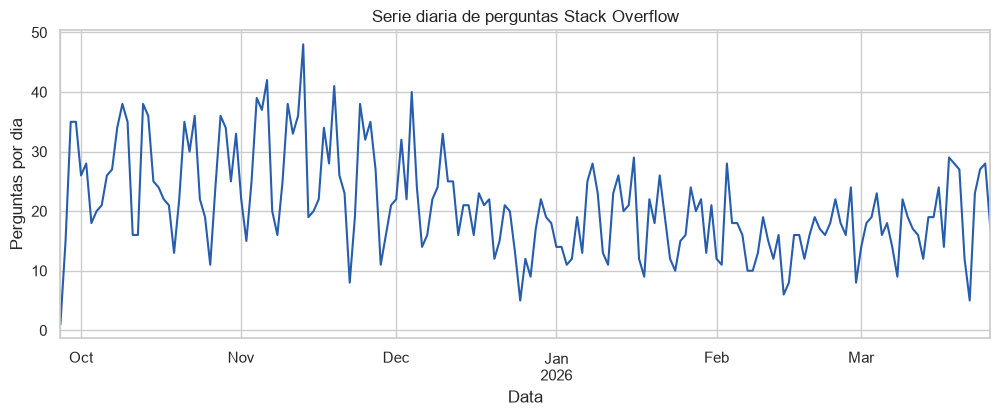

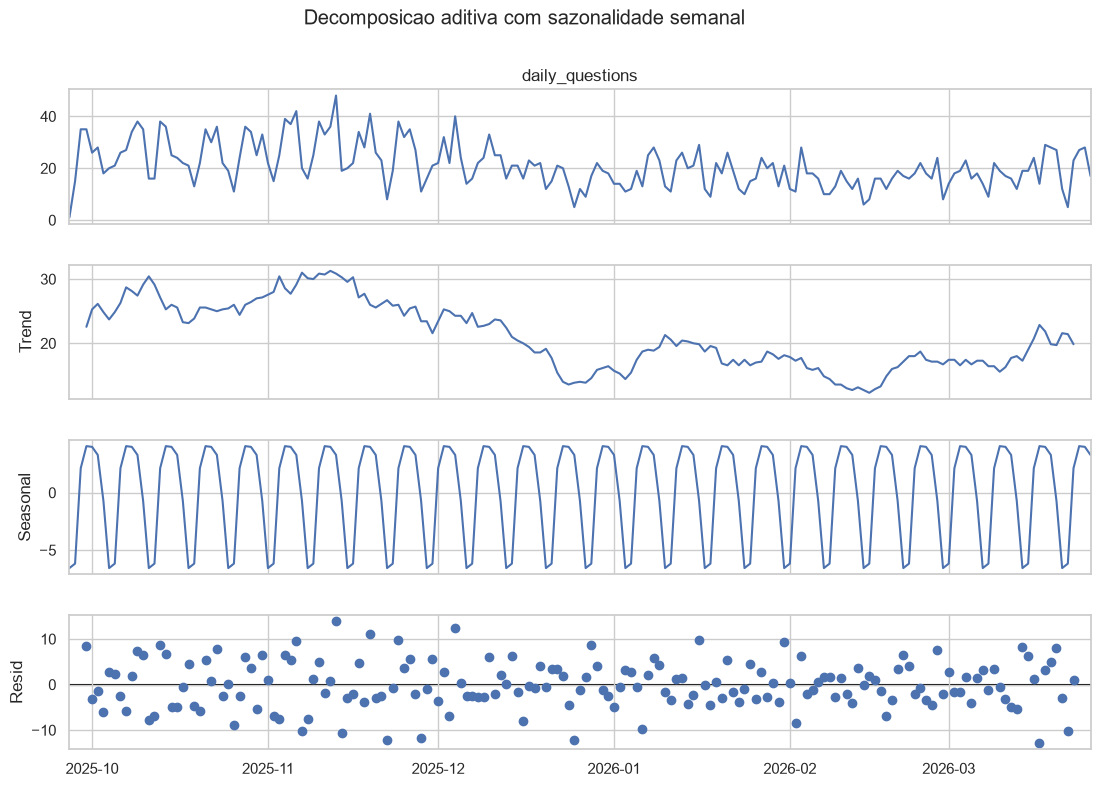

,mean,median,count
dia_semana,,,
Friday,20.360000,20.0,25
Monday,23.576923,22.0,26
Saturday,13.961538,14.0,26
Sunday,14.884615,15.0,26
Thursday,24.153846,23.0,26
Tuesday,25.269231,25.0,26
Wednesday,25.307692,25.0,26


,evidencia,resultado
0,serie_no_tempo,"volume diario continuo, com variacao semanal v..."
1,decomposicao,tendencia suave e componente sazonal semanal
2,qualidade,0 gaps diarios; outliers mantidos


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
daily[TARGET].plot(ax=ax, color="#275DAD")
ax.set_title("Serie diaria de perguntas Stack Overflow")
ax.set_xlabel("Data")
ax.set_ylabel("Perguntas por dia")
plt.show()

decomp = seasonal_decompose(daily[TARGET], model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Decomposicao aditiva com sazonalidade semanal", y=1.02)
plt.show()

weekday_profile = daily.assign(dia_semana=daily.index.day_name()).groupby("dia_semana")[TARGET].agg(["mean", "median", "count"])
display(weekday_profile)

evidencias_eda = pd.DataFrame(
    [
        {"evidencia": "serie_no_tempo", "resultado": "volume diario continuo, com variacao semanal visivel"},
        {"evidencia": "decomposicao", "resultado": "tendencia suave e componente sazonal semanal"},
        {"evidencia": "qualidade", "resultado": f"{len(missing_dates)} gaps diarios; outliers mantidos"},
    ]
)
display(evidencias_eda)

## 3. Engenharia de atributos

As features sao criadas apenas com informacao disponivel ate o dia anterior quando ha risco de vazamento. O `dropna()` remove as primeiras linhas invalidas geradas por lags e medias moveis.

In [4]:
feature_hypotheses = pd.DataFrame(
    [
        {"feature": "lag1", "hipotese": "o volume de hoje tende a se parecer com o de ontem"},
        {"feature": "lag7", "hipotese": "captura repeticao semanal do mesmo dia da semana"},
        {"feature": "lag14", "hipotese": "reforca padroes quinzenais e estabilidade recente"},
        {"feature": "rolling7", "hipotese": "resume tendencia curta sem usar o valor do proprio dia"},
        {"feature": "rolling14", "hipotese": "suaviza ruido e captura nivel recente"},
        {"feature": "dow_sin/dow_cos", "hipotese": "modela sazonalidade semanal de forma ciclica"},
        {"feature": "month_sin/month_cos", "hipotese": "modela mudancas sazonais ao longo dos meses"},
        {"feature": "is_weekend", "hipotese": "fins de semana podem ter menor atividade"},
        {"feature": "trend", "hipotese": "captura mudanca gradual de nivel no periodo"},
    ]
)
display(feature_hypotheses)

supervised = add_time_features(daily)
train_df, test_df = temporal_split(supervised, train_size=0.8)
train_y = train_df[TARGET]
test_y = test_df[TARGET]

print("Dataset com features:", supervised.shape)
print("Treino:", train_df.index.min().date(), "->", train_df.index.max().date(), train_df.shape)
print("Teste:", test_df.index.min().date(), "->", test_df.index.max().date(), test_df.shape)
display(supervised.head())

,feature,hipotese
0,lag1,o volume de hoje tende a se parecer com o de o...
1,lag7,captura repeticao semanal do mesmo dia da semana
2,lag14,reforca padroes quinzenais e estabilidade recente
3,rolling7,resume tendencia curta sem usar o valor do pro...
4,rolling14,suaviza ruido e captura nivel recente
5,dow_sin/dow_cos,modela sazonalidade semanal de forma ciclica
6,month_sin/month_cos,modela mudancas sazonais ao longo dos meses
7,is_weekend,fins de semana podem ter menor atividade
8,trend,captura mudanca gradual de nivel no periodo


Dataset com features: (167, 12)
Treino: 2025-10-11 -> 2026-02-20 (133, 12)
Teste: 2026-02-21 -> 2026-03-26 (34, 12)


,daily_questions,lag1,lag7,lag14,rolling7,rolling14,dow_sin,dow_cos,month_sin,month_cos,is_weekend,trend
date,,,,,,,,,,,,
2025-10-11,16,35.0,20.0,1.0,28.714286,25.642857,-0.974928,-0.222521,-0.866025,0.5,1,14
2025-10-12,16,16.0,21.0,15.0,28.142857,26.714286,-0.781831,0.623490,-0.866025,0.5,1,15
2025-10-13,38,16.0,26.0,35.0,27.428571,26.785714,0.000000,1.000000,-0.866025,0.5,0,16
2025-10-14,36,38.0,27.0,35.0,29.142857,27.000000,0.781831,0.623490,-0.866025,0.5,0,17
2025-10-15,25,36.0,34.0,26.0,30.428571,27.071429,0.974928,-0.222521,-0.866025,0.5,0,18


## 4. Baselines e regua de desempenho

In [5]:
results = []
predictions = {}

baseline_naive = baseline_persistence(train_y, test_y)
baseline_ma7 = baseline_moving_average(train_y, test_y, window=7)

for result in [baseline_naive, baseline_ma7]:
    results.append({"modelo": result.name, **result.metrics, **{"familia": "baseline"}})
    predictions[result.name] = result.y_pred
    log_wandb_run(result.name, result.metrics, result.params, test_y, result.y_pred, PROJECT_NAME)

regua = pd.DataFrame(results).sort_values("rmse_teste")
display(regua)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


mae_teste,▁
mape_teste,▁
rmse_teste,▁
mae_teste,5.58824
mape_teste,37.72852
rmse_teste,7.40429


mae_teste,▁
mape_teste,▁
rmse_teste,▁
mae_teste,4.76891
mape_teste,35.50717
rmse_teste,6.06779


,modelo,mae_teste,rmse_teste,mape_teste,familia
1,baseline_media_movel_7,4.768908,6.067794,35.507173,baseline
0,baseline_persistencia,5.588235,7.404291,37.728524,baseline


## 5. Estacionariedade, ACF/PACF e AIC

C:\Users\gabri\AppData\Local\Temp\ipykernel_17708\3845203715.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(daily[TARGET], regression="c", nlags="auto")


,serie,adf_pvalor,kpss_pvalor
0,original,0.456328,0.01
1,diferenciada_1,0.000058,NaN


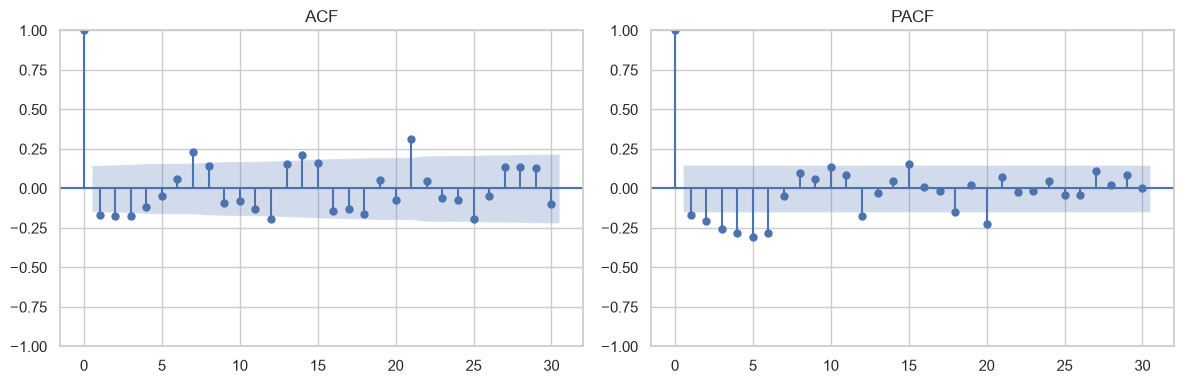

,evidencia,resultado
0,serie_no_tempo,"volume diario continuo, com variacao semanal v..."
1,decomposicao,tendencia suave e componente sazonal semanal
2,qualidade,0 gaps diarios; outliers mantidos
3,ADF original,p=0.4563; serie nao estacionaria; usar diferen...
4,ADF diferenciada,p=0.0001; usada como apoio para p/q
5,ACF/PACF,sugere testar termos curtos de AR e MA e sazon...


In [6]:
adf_original = adfuller(daily[TARGET])
diff_series = daily[TARGET].diff().dropna()
adf_diff = adfuller(diff_series)

try:
    kpss_stat, kpss_p, _, _ = kpss(daily[TARGET], regression="c", nlags="auto")
except Exception:
    kpss_stat, kpss_p = np.nan, np.nan

stationarity_table = pd.DataFrame(
    [
        {"serie": "original", "adf_pvalor": adf_original[1], "kpss_pvalor": kpss_p},
        {"serie": "diferenciada_1", "adf_pvalor": adf_diff[1], "kpss_pvalor": np.nan},
    ]
)
display(stationarity_table)

serie_para_acf = diff_series if adf_original[1] >= 0.05 else daily[TARGET]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(serie_para_acf, lags=30, ax=axes[0])
plot_pacf(serie_para_acf, lags=30, ax=axes[1], method="ywm")
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

interpretacao_adf = "estacionaria" if adf_original[1] < 0.05 else "nao estacionaria; usar diferenciacao ou componente integrado"
evidencias_modelagem = pd.concat(
    [
        evidencias_eda,
        pd.DataFrame(
            [
                {"evidencia": "ADF original", "resultado": f"p={adf_original[1]:.4f}; serie {interpretacao_adf}"},
                {"evidencia": "ADF diferenciada", "resultado": f"p={adf_diff[1]:.4f}; usada como apoio para p/q"},
                {"evidencia": "ACF/PACF", "resultado": "sugere testar termos curtos de AR e MA e sazonalidade semanal"},
            ]
        ),
    ],
    ignore_index=True,
)
display(evidencias_modelagem)

## 6. Modelo 1 - SARIMAX

In [7]:
sarimax_result, aic_table, sarimax_fit = fit_sarimax_grid(train_y, test_y)
display(aic_table)
results.append({"modelo": sarimax_result.name, **sarimax_result.metrics, "familia": "SARIMAX"})
predictions[sarimax_result.name] = sarimax_result.y_pred
log_wandb_run(sarimax_result.name, sarimax_result.metrics, sarimax_result.params, test_y, sarimax_result.y_pred, PROJECT_NAME)
display(pd.DataFrame(results).sort_values("rmse_teste"))

,order,seasonal_order,aic,status
14,"(1, 1, 1)","(0, 1, 1, 7)",763.020666,ok
17,"(2, 1, 1)","(0, 1, 1, 7)",764.218260,ok
8,"(1, 0, 1)","(0, 1, 1, 7)",767.932356,ok
11,"(2, 0, 1)","(0, 1, 1, 7)",769.930515,ok
2,"(0, 0, 1)","(0, 1, 1, 7)",776.961447,ok
5,"(1, 0, 0)","(0, 1, 1, 7)",781.959205,ok
13,"(1, 1, 1)","(1, 0, 1, 7)",800.366676,ok
16,"(2, 1, 1)","(1, 0, 1, 7)",802.341801,ok
7,"(1, 0, 1)","(1, 0, 1, 7)",803.089015,ok
10,"(2, 0, 1)","(1, 0, 1, 7)",805.082039,ok


mae_teste,▁
mape_teste,▁
rmse_teste,▁
mae_teste,7.40618
mape_teste,36.95394
rmse_teste,9.01124


,modelo,mae_teste,rmse_teste,mape_teste,familia
1,baseline_media_movel_7,4.768908,6.067794,35.507173,baseline
0,baseline_persistencia,5.588235,7.404291,37.728524,baseline
2,"sarimax_(1, 1, 1)_(0, 1, 1, 7)",7.406180,9.011238,36.953941,SARIMAX


## 7. Modelo 2 - Suavizacao exponencial

In [8]:
smooth_result, smooth_fit = fit_exponential_smoothing(train_y, test_y)
results.append({"modelo": smooth_result.name, **smooth_result.metrics, "familia": "suavizacao"})
predictions[smooth_result.name] = smooth_result.y_pred
log_wandb_run(smooth_result.name, smooth_result.metrics, smooth_result.params, test_y, smooth_result.y_pred, PROJECT_NAME)
display(pd.DataFrame(results).sort_values("rmse_teste"))

mae_teste,▁
mape_teste,▁
rmse_teste,▁
mae_teste,6.88776
mape_teste,35.57041
rmse_teste,8.58291


,modelo,mae_teste,rmse_teste,mape_teste,familia
1,baseline_media_movel_7,4.768908,6.067794,35.507173,baseline
0,baseline_persistencia,5.588235,7.404291,37.728524,baseline
3,holtwinters_add_weekly,6.887757,8.582905,35.570410,suavizacao
2,"sarimax_(1, 1, 1)_(0, 1, 1, 7)",7.406180,9.011238,36.953941,SARIMAX


## 8. Modelo 3 - ML tabular e overfitting

In [9]:
ml_result, ml_model, ml_train_metrics = fit_ml_model(train_df, test_df, DEFAULT_FEATURES, complex_model=False)
complex_result, complex_model, complex_train_metrics = fit_ml_model(train_df, test_df, DEFAULT_FEATURES, complex_model=True)

for result, train_metrics, familia in [
    (ml_result, ml_train_metrics, "ML"),
    (complex_result, complex_train_metrics, "ML_overfitting_check"),
]:
    results.append({"modelo": result.name, **result.metrics, **train_metrics, "familia": familia})
    predictions[result.name] = result.y_pred
    log_wandb_run(result.name, result.metrics, result.params, test_y, result.y_pred, PROJECT_NAME)

overfit_table = pd.DataFrame(
    [
        {"modelo": ml_result.name, **ml_train_metrics, **ml_result.metrics},
        {"modelo": complex_result.name, **complex_train_metrics, **complex_result.metrics},
    ]
)
display(overfit_table)
display(pd.DataFrame(results).sort_values("rmse_teste"))

mae_teste,▁
mape_teste,▁
rmse_teste,▁
mae_teste,4.74812
mape_teste,28.14317
rmse_teste,5.77613


mae_teste,▁
mape_teste,▁
rmse_teste,▁
mae_teste,5.14706
mape_teste,33.29649
rmse_teste,6.28958


,modelo,mae_treino,rmse_treino,mae_teste,rmse_teste,mape_teste
0,gradient_boosting,3.006172,3.848997,4.748122,5.776128,28.143170
1,decision_tree_complexa,0.000000,0.000000,5.147059,6.289581,33.296489


,modelo,mae_teste,rmse_teste,mape_teste,familia,mae_treino,rmse_treino
4,gradient_boosting,4.748122,5.776128,28.143170,ML,3.006172,3.848997
1,baseline_media_movel_7,4.768908,6.067794,35.507173,baseline,NaN,NaN
5,decision_tree_complexa,5.147059,6.289581,33.296489,ML_overfitting_check,0.000000,0.000000
0,baseline_persistencia,5.588235,7.404291,37.728524,baseline,NaN,NaN
3,holtwinters_add_weekly,6.887757,8.582905,35.570410,suavizacao,NaN,NaN
2,"sarimax_(1, 1, 1)_(0, 1, 1, 7)",7.406180,9.011238,36.953941,SARIMAX,NaN,NaN


**Conclusao sobre overfitting.** O modelo mais complexo deve ser aceito apenas se reduzir erro de teste, nao apenas erro de treino. Quando o ganho aparece somente no treino, a complexidade esta memorizando variacoes historicas especificas e perde robustez para dias futuros.

## 9. Avaliacao, leaderboard e diagnostico de residuos

,modelo,mae_teste,rmse_teste,mape_teste,familia,mae_treino,rmse_treino
0,gradient_boosting,4.748122,5.776128,28.143170,ML,3.006172,3.848997
1,baseline_media_movel_7,4.768908,6.067794,35.507173,baseline,NaN,NaN
2,decision_tree_complexa,5.147059,6.289581,33.296489,ML_overfitting_check,0.000000,0.000000
3,baseline_persistencia,5.588235,7.404291,37.728524,baseline,NaN,NaN
4,holtwinters_add_weekly,6.887757,8.582905,35.570410,suavizacao,NaN,NaN
5,"sarimax_(1, 1, 1)_(0, 1, 1, 7)",7.406180,9.011238,36.953941,SARIMAX,NaN,NaN


,modelo,familia,mae_teste,rmse_teste,mape_teste
0,gradient_boosting,ML,4.748122,5.776128,28.143170
1,baseline_media_movel_7,baseline,4.768908,6.067794,35.507173
2,decision_tree_complexa,ML_overfitting_check,5.147059,6.289581,33.296489
3,baseline_persistencia,baseline,5.588235,7.404291,37.728524
4,holtwinters_add_weekly,suavizacao,6.887757,8.582905,35.570410
5,"sarimax_(1, 1, 1)_(0, 1, 1, 7)",SARIMAX,7.406180,9.011238,36.953941


Modelo campeao: gradient_boosting


,lb_stat,lb_pvalue
14,15.881203,0.320683


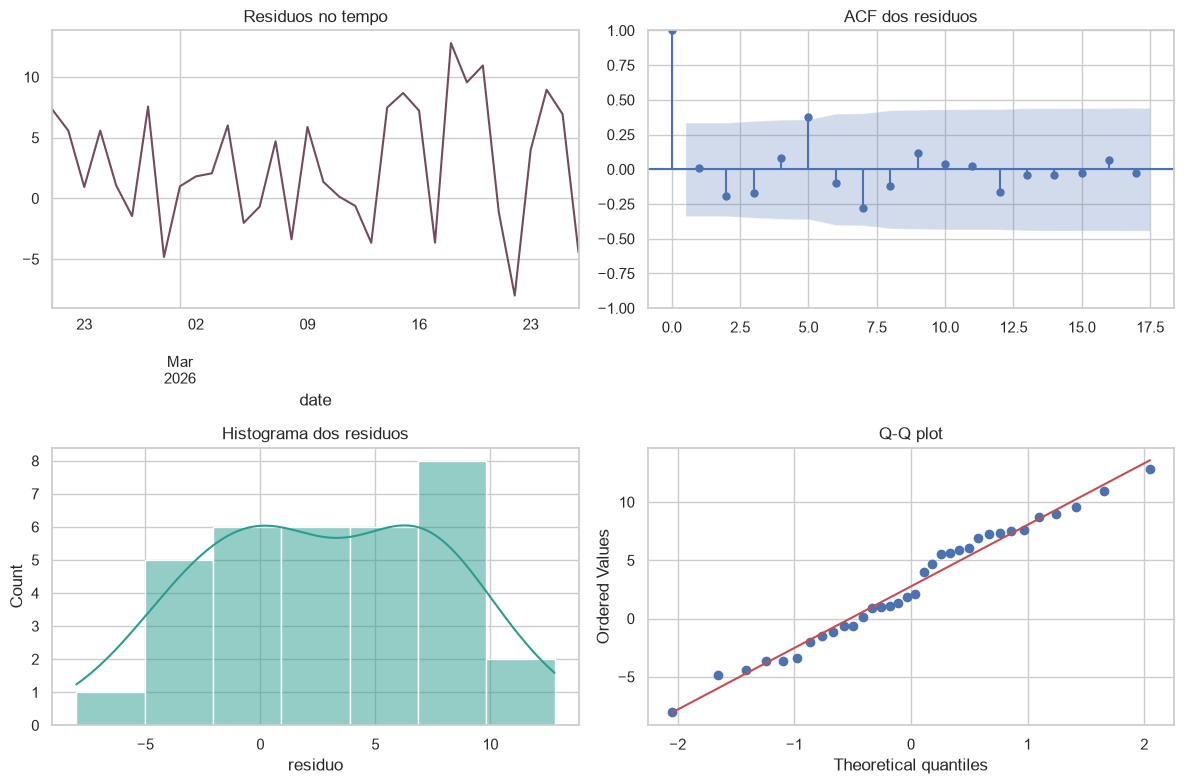

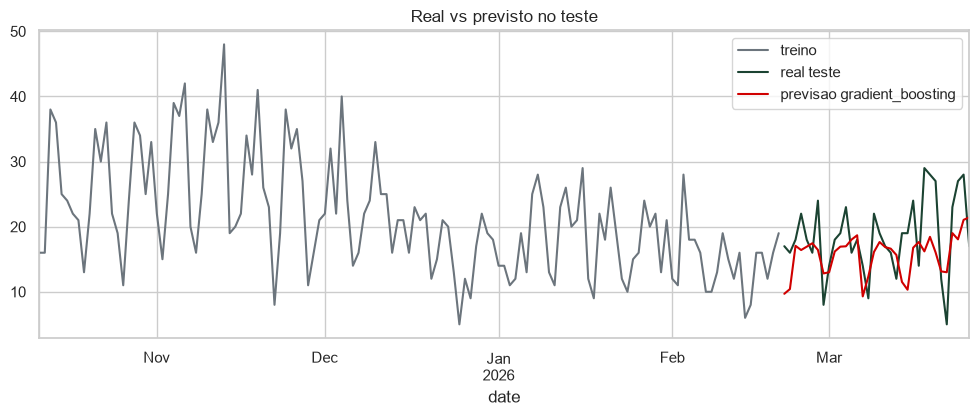

In [10]:
metrics_table = pd.DataFrame(results).sort_values("rmse_teste").reset_index(drop=True)
display(metrics_table)

leaderboard = metrics_table[["modelo", "familia", "mae_teste", "rmse_teste", "mape_teste"]].copy()
display(leaderboard)

champion_name = leaderboard.iloc[0]["modelo"]
champion_pred = predictions[champion_name]
residuals = (test_y - champion_pred).rename("residuo")
print("Modelo campeao:", champion_name)
display(residual_diagnostics(residuals))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
residuals.plot(ax=axes[0, 0], color="#734B5E")
axes[0, 0].set_title("Residuos no tempo")
plot_acf(residuals.dropna(), lags=min(20, len(residuals.dropna()) // 2), ax=axes[0, 1])
axes[0, 1].set_title("ACF dos residuos")
sns.histplot(residuals.dropna(), kde=True, ax=axes[1, 0], color="#2A9D8F")
axes[1, 0].set_title("Histograma dos residuos")
stats.probplot(residuals.dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
train_y.plot(ax=ax, label="treino", color="#6C757D")
test_y.plot(ax=ax, label="real teste", color="#1B4332")
champion_pred.plot(ax=ax, label=f"previsao {champion_name}", color="#D00000")
ax.set_title("Real vs previsto no teste")
ax.legend()
plt.show()

Se o Ljung-Box indicar autocorrelacao remanescente nos residuos, o refinamento recomendado e ampliar a busca SARIMAX com termos sazonais alternativos ou testar exogenas derivadas do calendario. Se os residuos forem aproximadamente ruido branco, o campeao e adequado para o horizonte operacional proposto.

## 10. Validacao temporal walk-forward

In [11]:
wf_order = sarimax_result.params["order"]
wf_seasonal_order = sarimax_result.params["seasonal_order"]
walk_forward = walk_forward_sarimax(supervised[TARGET], wf_order, wf_seasonal_order, initial_window=120, step=7)
display(walk_forward)
walk_forward_summary = walk_forward[["mae_teste", "rmse_teste", "mape_teste"]].mean().to_frame("media_walk_forward").T
display(walk_forward_summary)

print("Trade-off: walk-forward e mais caro porque reestima o modelo varias vezes, mas mede robustez em cortes temporais sucessivos em vez de depender de um unico holdout.")

,inicio_teste,fim_teste,n_teste,mae_teste,rmse_teste,mape_teste
0,2026-02-08,2026-02-14,7,3.435044,3.973931,31.730478
1,2026-02-15,2026-02-21,7,3.792286,4.925489,23.693421
2,2026-02-22,2026-02-28,7,3.806988,4.748773,21.566158
3,2026-03-01,2026-03-07,7,2.061846,2.581538,11.810315
4,2026-03-08,2026-03-14,7,3.973779,4.439464,27.231845
5,2026-03-15,2026-03-21,7,7.378302,8.046013,32.497779
6,2026-03-22,2026-03-26,5,5.155670,6.276191,58.567346


,mae_teste,rmse_teste,mape_teste
media_walk_forward,4.229131,4.998771,29.585334


Trade-off: walk-forward e mais caro porque reestima o modelo varias vezes, mas mede robustez em cortes temporais sucessivos em vez de depender de um unico holdout.


## 11. Previsao final de 30 dias

,previsao,limite_inferior_95,limite_superior_95
2026-03-27,20.970897,9.221584,32.720211
2026-03-28,15.209207,3.282763,27.135650
2026-03-29,14.098331,2.059841,26.136821
2026-03-30,22.321273,10.174059,34.468486
2026-03-31,22.957043,10.702171,35.211915
2026-04-01,24.324620,11.963030,36.686209
2026-04-02,21.185187,8.717794,33.652580
2026-04-03,21.447233,8.469906,34.424559
2026-04-04,15.529177,2.403756,28.654597
2026-04-05,14.411708,1.149877,27.673540


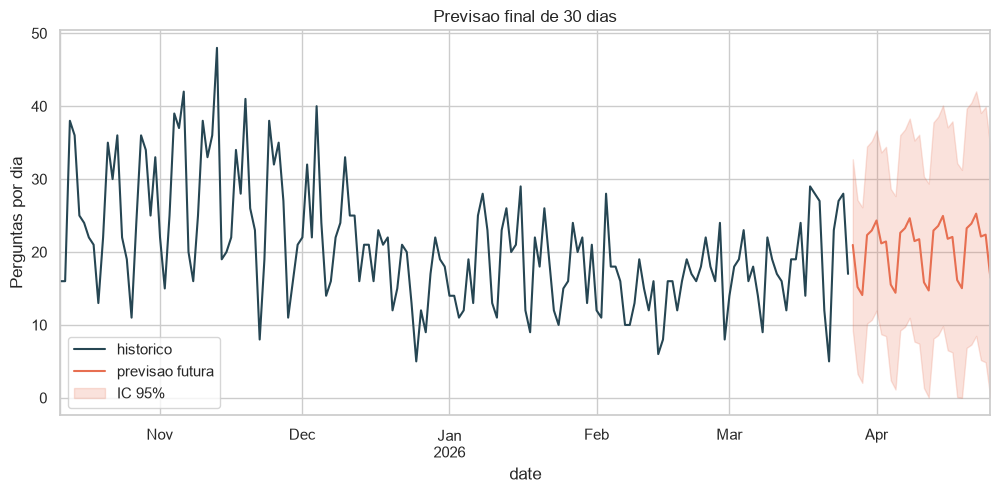

In [12]:
horizon = 30
full_series = supervised[TARGET]

# Para previsao futura com intervalo, usamos a familia SARIMAX como modelo estatistico explicavel e reestimamos na serie completa disponivel.
from statsmodels.tsa.statespace.sarimax import SARIMAX
final_model = SARIMAX(
    full_series,
    order=sarimax_result.params["order"],
    seasonal_order=sarimax_result.params["seasonal_order"],
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

future = final_model.get_forecast(steps=horizon)
future_mean = future.predicted_mean.clip(lower=0)
future_ci = future.conf_int(alpha=0.05).clip(lower=0)
future_index = pd.date_range(full_series.index.max() + pd.Timedelta(days=1), periods=horizon, freq="D")
future_mean.index = future_index
future_ci.index = future_index

forecast_table = pd.DataFrame(
    {
        "previsao": future_mean,
        "limite_inferior_95": future_ci.iloc[:, 0],
        "limite_superior_95": future_ci.iloc[:, 1],
    }
)
display(forecast_table.head(10))

fig, ax = plt.subplots(figsize=(12, 5))
full_series.plot(ax=ax, label="historico", color="#264653")
future_mean.plot(ax=ax, label="previsao futura", color="#E76F51")
ax.fill_between(future_index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color="#E76F51", alpha=0.2, label="IC 95%")
ax.set_title("Previsao final de 30 dias")
ax.set_ylabel("Perguntas por dia")
ax.legend()
plt.show()

## 12. Storytelling executivo e recomendações

A previsão diaria de perguntas ajuda a estimar demanda de moderaçãao, suporte tecnico, curadoria de conteudo e monitoramento de interesse por tecnologias. Para um time de comunidade ou produto, a serie indica quando a atividade tende a subir ou cair e permite planejar capacidade.

As evidencias esperadas são: padrão semanal de atividade, flutuações naturais de volume e possivel tendencia de curto prazo dentro da janela coletada. A decisao do modelo campeão combina erro no teste, interpretabilidade e diagnostico de residuos. O wandb organiza essa comparacao em runs nomeados, facilita ordenar por RMSE e preserva parametros e graficos de cada tentativa.

Recomendacoes: atualizar a coleta periodicamente, reexecutar o notebook a cada nova janela, comparar o leaderboard antes de trocar o modelo em producao e investigar dias extremos antes de remove-los da serie.